# Setup and data loading


In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [6]:
# load dataset
data_path="../data/raw_nsw_coast_data_2016_2021.xlsx"
df=pd.read_excel(data_path,
                 sheet_name="2016 to 2021 data")
df.head()


,Number,Station,Catchment,Zone,Time stamp (Sampling),Electrical Conductivity @25 C / WCK - Determination of Conductivity in Water [µS/cm],Nitrogen - total / WCK - Simultaneous Determination of Total Nitrogen and Total Phosphorus using Persulphate Digestion [mg/L],Nitrate + nitrite as N (NOx) / WCK - Determination of Oxidised Nitrogen Nitrate & Nitrite in Water [mg/L],Phosphorus - total / WCK - Simultaneous Determination of Total Nitrogen and Total Phosphorus using Persulphate Digestion [mg/L],Phosphorus - reactive (orthophosphate) - dissolved / WCK - Determination of Reactive Phosphorus [mg/L],Solids - total suspended @ 105 C / WCK - Total Suspended Solids at 105°C [mg/L],Turbidity / Field - Determination of turbidity by nephelometry using HACH turbidimeter [NTU],Oxygen - dissolved saturation / Field - Water quality sonde [% sat],pH / Field - Water quality sonde [---]
0,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-06-28 11:45:00,230.0,1.10,0.42,0.240,0.140,13.0,34.0,NaN,NaN
1,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-08-18 12:27:00,260.0,0.52,0.19,0.150,0.110,10.0,16.9,108.0,7.8
2,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-09-29 11:18:00,340.0,0.36,0.01,0.099,0.068,10.0,5.4,101.0,8.1
3,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-10-26 10:21:00,350.0,0.22,0.01,0.088,0.068,10.0,5.7,112.0,8.3
4,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-11-29 08:57:00,330.0,0.28,0.01,0.140,0.120,10.0,6.8,119.0,8.2


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 14 columns):
 #   Column                                                                                                                           Non-Null Count  Dtype         
---  ------                                                                                                                           --------------  -----         
 0   Number                                                                                                                           1484 non-null   int64         
 1   Station                                                                                                                          1484 non-null   str           
 2   Catchment                                                                                                                        1484 non-null   str           
 3   Zone                                                                      

#### This is a relatively clean dataset with 1484 rows,14 columns and low missing values. 
#### sincee the column names are very long, we rename the columns 

In [9]:
df.columns = [
    "number",
    "station",
    "catchment",
    "zone",
    "sample_date",
    "ec_us_cm",          # Electrical Conductivity
    "total_n_mg_l",      # Total Nitrogen
    "nox_n_mg_l",        # Nitrate + Nitrite as N
    "total_p_mg_l",      # Total Phosphorus
    "reactive_p_mg_l",   # Reactive Phosphorus (orthophosphate)
    "tss_mg_l",          # Total Suspended Solids
    "turbidity_ntu",     # Turbidity
    "do_sat_pct",        # Dissolved Oxygen % saturation
    "ph"                 # pH
]

df.head()

,number,station,catchment,zone,sample_date,ec_us_cm,total_n_mg_l,nox_n_mg_l,total_p_mg_l,reactive_p_mg_l,tss_mg_l,turbidity_ntu,do_sat_pct,ph
0,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-06-28 11:45:00,230.0,1.10,0.42,0.240,0.140,13.0,34.0,NaN,NaN
1,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-08-18 12:27:00,260.0,0.52,0.19,0.150,0.110,10.0,16.9,108.0,7.8
2,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-09-29 11:18:00,340.0,0.36,0.01,0.099,0.068,10.0,5.4,101.0,8.1
3,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-10-26 10:21:00,350.0,0.22,0.01,0.088,0.068,10.0,5.7,112.0,8.3
4,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-11-29 08:57:00,330.0,0.28,0.01,0.140,0.120,10.0,6.8,119.0,8.2


In [10]:
## adding time features such as year and month by extracting from sample_date column
df["year"] = df["sample_date"].dt.year
df["month"] = df["sample_date"].dt.month

def get_season(m):
    if m in [12, 1, 2]: return "summer"
    if m in [3, 4, 5]:  return "autumn"
    if m in [6, 7, 8]:  return "winter"
    return "spring"

df["season"] = df["month"].apply(get_season)

In [12]:
#check new columns now
df.columns

Index(['number', 'station', 'catchment', 'zone', 'sample_date', 'ec_us_cm', 'total_n_mg_l', 'nox_n_mg_l',
       'total_p_mg_l', 'reactive_p_mg_l', 'tss_mg_l', 'turbidity_ntu', 'do_sat_pct', 'ph', 'year', 'month', 'season'],
      dtype='str')

C:\Users\rosis\AppData\Local\Temp\ipykernel_5504\175150409.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values * 100, y=missing.index, palette="Reds_r")


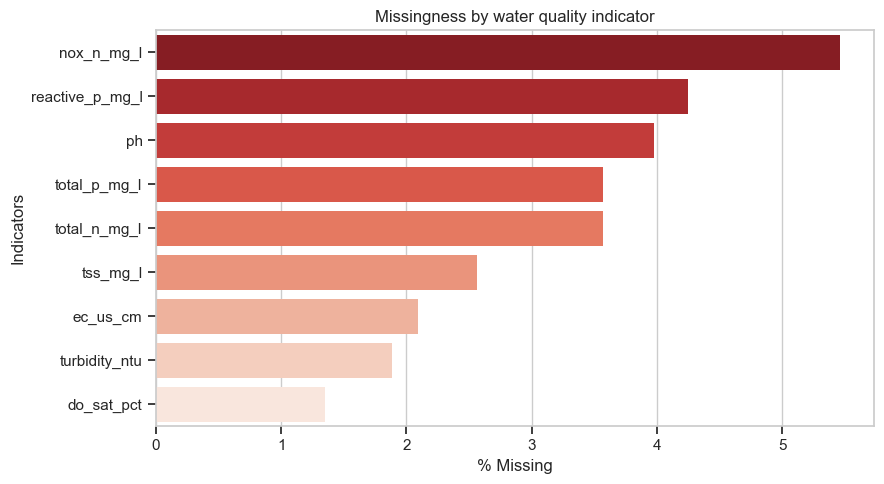

nox_n_mg_l         5.458221
reactive_p_mg_l    4.245283
ph                 3.975741
total_p_mg_l       3.571429
total_n_mg_l       3.571429
tss_mg_l           2.560647
ec_us_cm           2.088949
turbidity_ntu      1.886792
do_sat_pct         1.347709
dtype: float64


In [16]:
### we check percentage of missing values in indicator columns
indicator_cols = [
    "ec_us_cm", "total_n_mg_l", "nox_n_mg_l",
    "total_p_mg_l", "reactive_p_mg_l", "tss_mg_l",
    "turbidity_ntu", "do_sat_pct", "ph"
]

missing = df[indicator_cols].isna().mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=missing.values * 100, y=missing.index, palette="Reds_r")
plt.xlabel("% Missing")
plt.ylabel("Indicators")
plt.title("Missingness by water quality indicator")
plt.tight_layout()
plt.savefig("../figures/01_missingness.png", dpi=150)
plt.show()

print(missing * 100)

#### Since all indicators have less than 7% missing values, we donot need to drop columns. We will impute missing values using median per station at the ML Modelling Part of the project

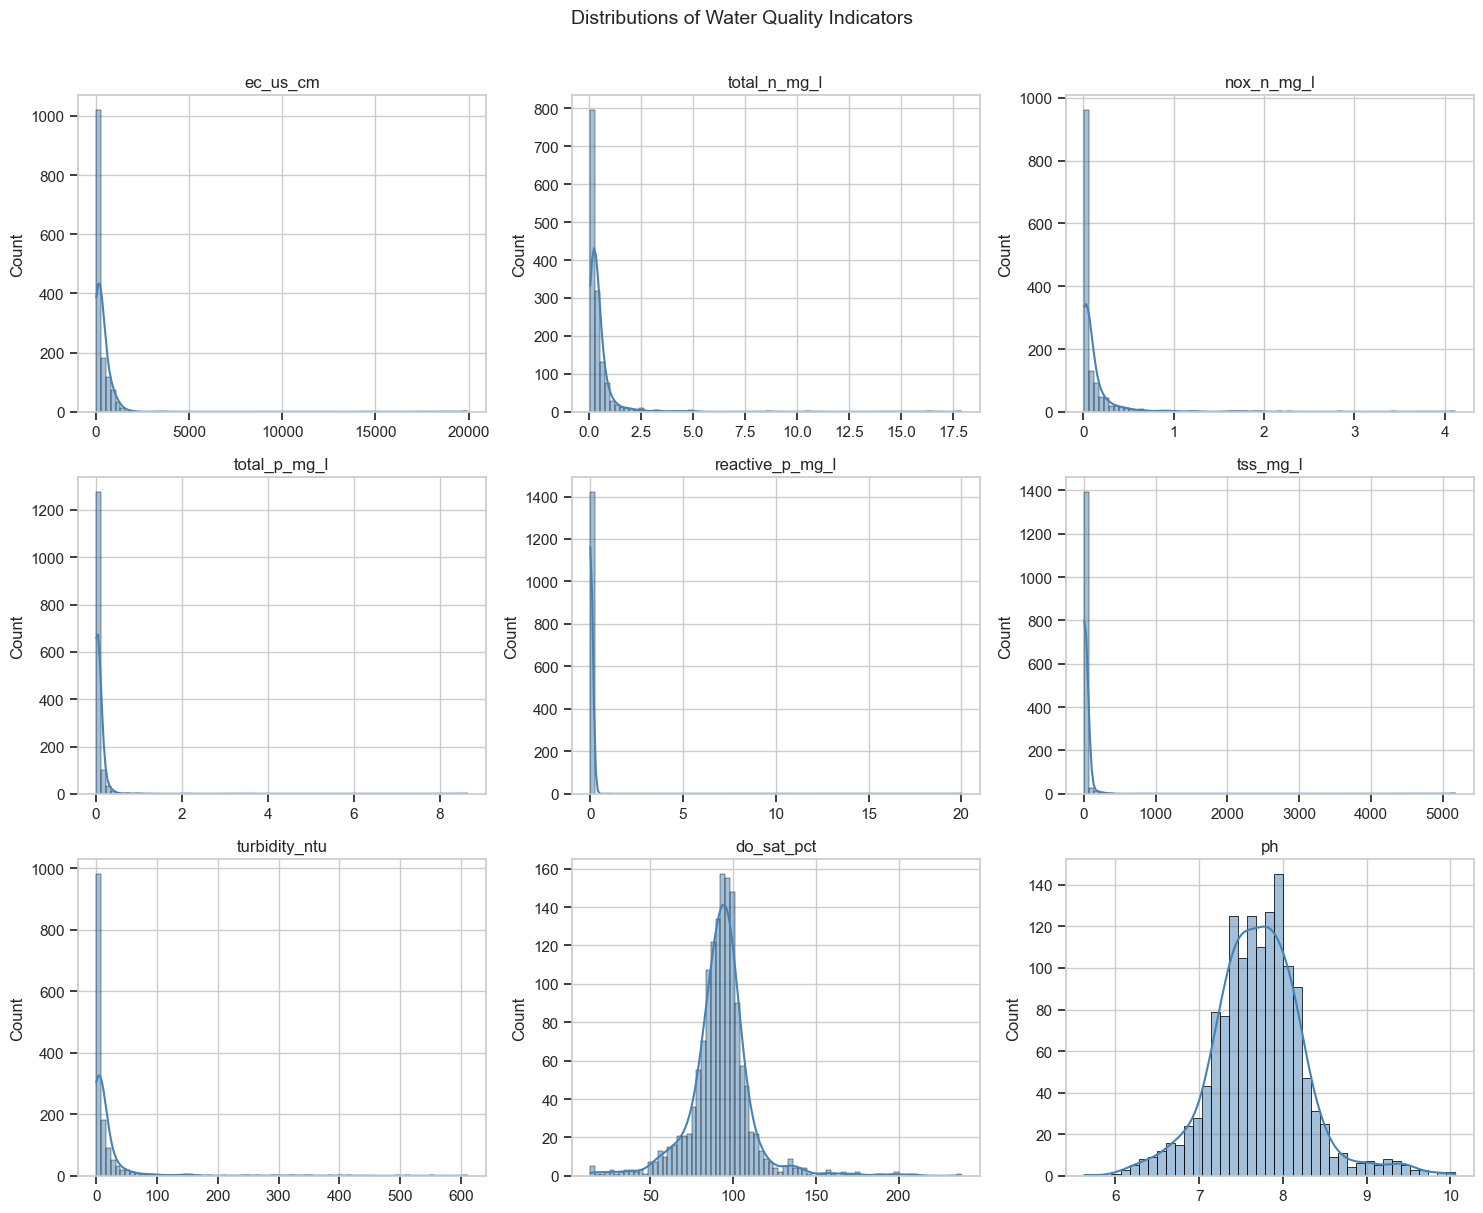

In [18]:
# Univariate Distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(indicator_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.suptitle("Distributions of Water Quality Indicators", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/02_univariate_distributions.png", dpi=150)
plt.show()

#### The univariate analysis shows that 'ec_us_cm', 'total_n_mg_l', 'nox_n_mg_l', 'total_p_mg_l', 'reactive_p_mg_l', 'tss_mg_l', 'turbidity_ntu' are right skewed and  'do_sat_pct', 'ph' are normally distributed. The right skewed indicators are candidates for log transform in ML modelling section. 

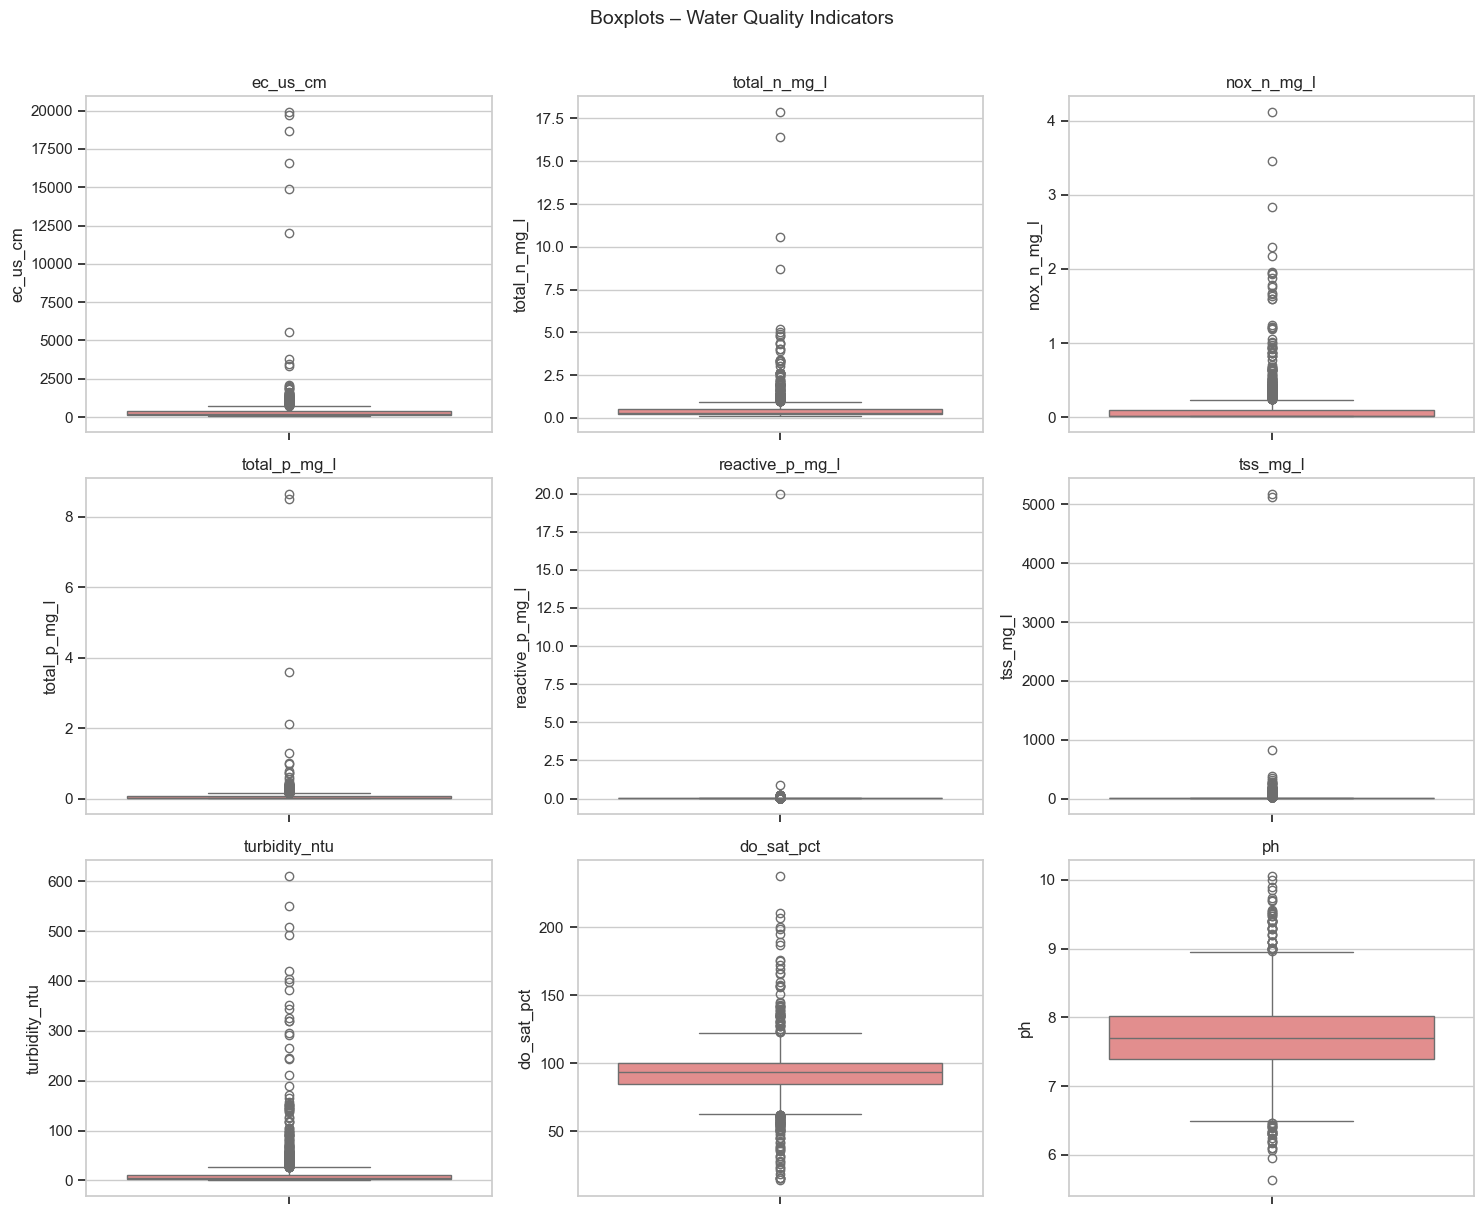

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(indicator_cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color="lightcoral")
    axes[i].set_title(col)

plt.suptitle("Boxplots – Water Quality Indicators", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/03_boxplots.png", dpi=150)
plt.show()

In [22]:
# SUmmary stats table
summary = df[indicator_cols].describe().T.round(3)
summary["missing_%"] = (df[indicator_cols].isna().mean() * 100).round(2)
summary.to_csv("../figures/04_summary_stats.csv")
summary

,count,mean,std,min,25%,50%,75%,max,missing_%
ec_us_cm,1453.0,385.057,1143.706,38.400,120.000,180.000,371.700,19934.00,2.09
total_n_mg_l,1431.0,0.495,0.912,0.080,0.200,0.300,0.500,17.90,3.57
nox_n_mg_l,1403.0,0.113,0.282,0.010,0.010,0.020,0.100,4.12,5.46
total_p_mg_l,1431.0,0.073,0.348,0.010,0.010,0.029,0.070,8.65,3.57
reactive_p_mg_l,1421.0,0.036,0.531,0.005,0.010,0.010,0.020,20.00,4.25
tss_mg_l,1446.0,24.560,194.830,5.000,5.000,10.000,11.000,5180.00,2.56
turbidity_ntu,1456.0,16.647,47.707,0.020,1.908,3.950,11.600,611.00,1.89
do_sat_pct,1464.0,92.586,19.439,13.700,85.000,93.200,100.025,238.00,1.35
ph,1425.0,7.713,0.556,5.630,7.400,7.700,8.020,10.06,3.98


In [23]:
# Per catchment and per station overview
print("Unique catchments:", df["catchment"].nunique())
print("Unique stations:", df["station"].nunique())
print("Unique zones:", df["zone"].nunique())
print("\nSamples per catchment:\n", df["catchment"].value_counts())

Unique catchments: 15
Unique stations: 27
Unique zones: 6

Samples per catchment:
 catchment
Hunter       390
Clarence     161
Bega         113
Karuah       112
Manning      109
Richmond     105
Tweed         56
Macleay       55
Bellinger     55
Hastings      55
Clyde         55
Tuross        55
Towamba       55
Moruya        54
Snowy         54
Name: count, dtype: int64


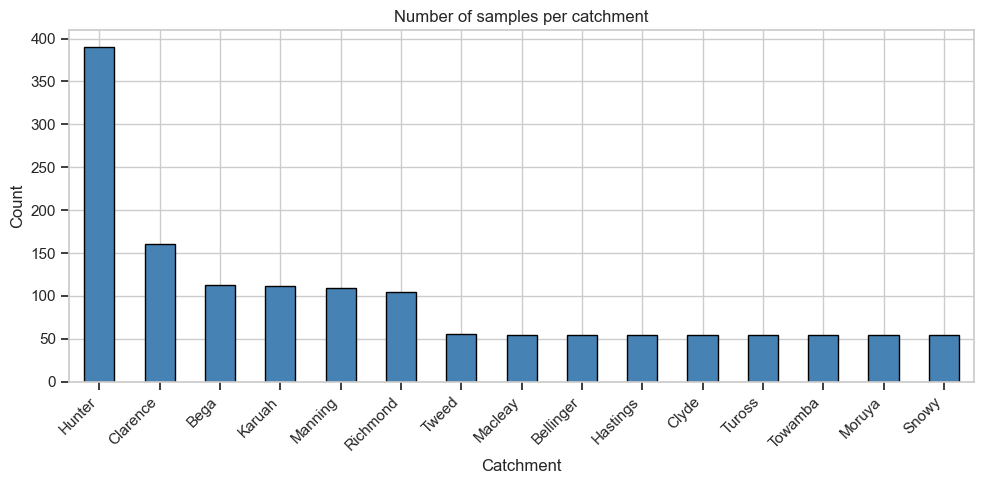

In [26]:
## plotting number of samples per catchment
plt.figure(figsize=(10, 5))
df["catchment"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Number of samples per catchment")
plt.xlabel("Catchment")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/05_samples_per_catchment.png", dpi=150)
plt.show()

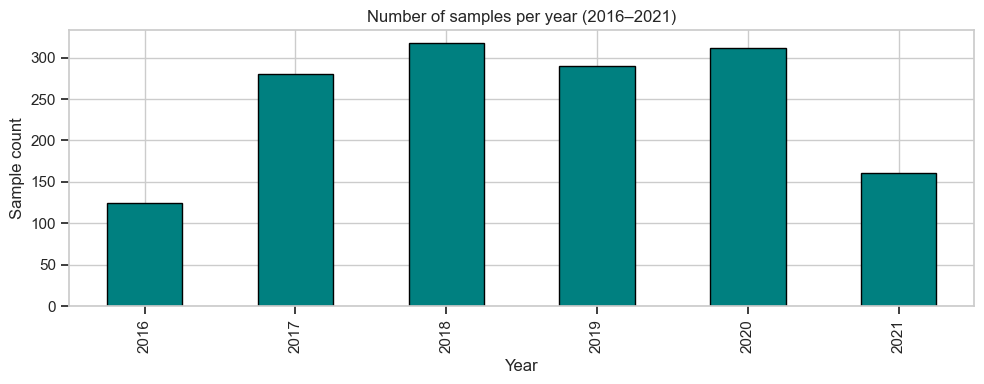

In [ ]:
# plotting number of samples per year
plt.figure(figsize=(10, 4))
df.groupby("year").size().plot(kind="bar", color="teal", edgecolor="black")
plt.title("Number of samples per year (2016–2021)")
plt.xlabel("Year")
plt.ylabel("Sample count")
plt.tight_layout()
plt.savefig("../figures/06_samples_per_year.png", dpi=150)
plt.show()